# SECTION 1 : Régression Linéaire

# 1.1 Lire les données 


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [4]:
url = "https://raw.githubusercontent.com/aelyoussfi/TP_IA_ECM/refs/heads/main/Salary_dataset.csv"
df = pd.read_csv(url)

print("Aperçu du dataset:")
print(df.head(10))
print(f"\nDimensions: {df.shape}")
print(f"\nValeurs manquantes:\n{df.isnull().sum()}")
df

Aperçu du dataset:
   Unnamed: 0  YearsExperience   Salary
0           0              1.2  39344.0
1           1              1.4  46206.0
2           2              1.6  37732.0
3           3              2.1  43526.0
4           4              2.3  39892.0
5           5              3.0  56643.0
6           6              3.1  60151.0
7           7              3.3  54446.0
8           8              3.3  64446.0
9           9              3.8  57190.0

Dimensions: (30, 3)

Valeurs manquantes:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


# 1.2 Préparer les données 


In [7]:

# Supprimer les lignes avec Salary manquante
df_clean = df.dropna(subset=['Salary']).copy()

# Remplir les valeurs manquantes des features avec la médiane
for col in df_clean.columns[:-1]:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Séparer features (X) et cible (y)
X = df_clean[['YearsExperience']]
y = df_clean['Salary']

# Découpage train/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Taille train : {X_train_scaled.shape[0]}")
print(f"Taille test  : {X_test_scaled.shape[0]}")

Taille train : 24
Taille test  : 6


# 1.3 Entraîner le modèle

Modèle entraîné ✓
Coefficient (pente)   : 27151.54
Intercept (ordonnée)  : 74208.63


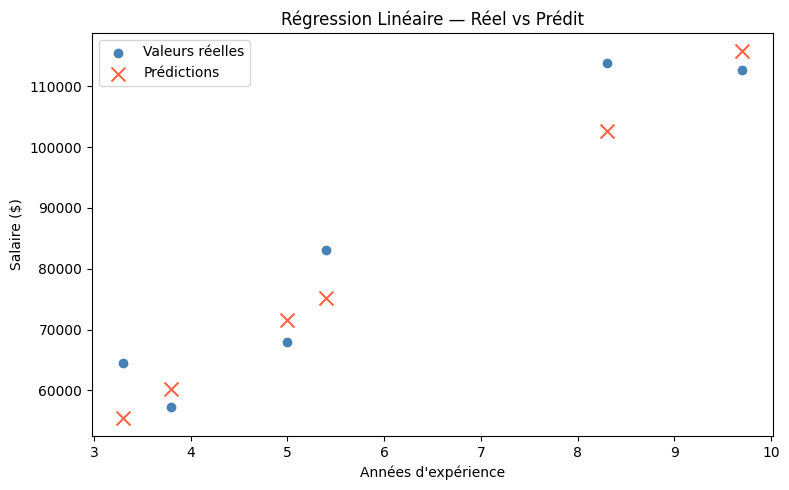

In [8]:

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lr = lin_reg.predict(X_test_scaled)

print("Modèle entraîné ✓")
print(f"Coefficient (pente)   : {lin_reg.coef_[0]:.2f}")
print(f"Intercept (ordonnée)  : {lin_reg.intercept_:.2f}")

# Visualisation
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='steelblue', label='Valeurs réelles')
plt.scatter(X_test, y_pred_lr, color='tomato', label='Prédictions', marker='x', s=100)
plt.xlabel("Années d'expérience")
plt.ylabel("Salaire ($)")
plt.title("Régression Linéaire — Réel vs Prédit")
plt.legend()
plt.tight_layout()
plt.show()

#  1.4 Afficher les métriques

In [9]:

mae  = mean_absolute_error(y_test, y_pred_lr)
mse  = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_lr)

print("=== Régression Linéaire ===")
print(f"MAE  (Erreur Absolue Moyenne)      : {mae:.2f}")
print(f"MSE  (Erreur Quadratique Moyenne)  : {mse:.2f}")
print(f"RMSE (Racine de MSE)               : {rmse:.2f}")
print(f"R²   (Coefficient de détermination): {r2:.4f}")

=== Régression Linéaire ===
MAE  (Erreur Absolue Moyenne)      : 6286.45
MSE  (Erreur Quadratique Moyenne)  : 49830096.86
RMSE (Racine de MSE)               : 7059.04
R²   (Coefficient de détermination): 0.9024


# SECTION 2 : Random Forest Regressor

In [ ]:

from sklearn.ensemble import RandomForestRegressor

# --- 2.1 Lire les données ---
# TODO: Charger le dataset depuis l'URL
url = ...
df2 = ...

print(df2.head())

# --- 2.2 Préparer les données ---
# TODO: Nettoyer les valeurs manquantes
df2_clean = ...

X2 = ...
y2 = ...

X2_train, X2_test, y2_train, y2_test = train_test_split(
    ..., ..., test_size=..., random_state=42
)

scaler2 = StandardScaler()
X2_train_scaled = ...
X2_test_scaled  = ...

# --- 2.3 Entraîner le modèle ---
# TODO: Créer et entraîner un RandomForestRegressor
# Indice: paramètres utiles → n_estimators, random_state
rf_reg = RandomForestRegressor(...)
rf_reg....(..., ...)

y_pred_rf = ...

# --- 2.4 Afficher les métriques ---
# TODO: Calculer et afficher les 4 métriques
mae_rf  = ...
mse_rf  = ...
rmse_rf = ...
r2_rf   = ...

print("=== Random Forest Regressor ===")
print(f"MAE  : {...:.2f}")
print(f"MSE  : {...:.2f}")
print(f"RMSE : {...:.2f}")
print(f"R²   : {...:.4f}")

# SECTION 3 : Decision Tree Regressor 

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# --- 3.1 Lire les données ---
url = ...
df3 = ...

# --- 3.2 Préparer les données ---
df3_clean = ...

X3 = ...
y3 = ...

X3_train, X3_test, y3_train, y3_test = train_test_split(
    ..., ..., test_size=..., random_state=42
)

scaler3 = StandardScaler()
X3_train_scaled = ...
X3_test_scaled  = ...

# --- 3.3 Entraîner le modèle ---
# TODO: Créer et entraîner un DecisionTreeRegressor
# Indice: paramètre utile → max_depth
dt_reg = DecisionTreeRegressor(...)
dt_reg....(..., ...)

y_pred_dt = ...

# --- 3.4 Afficher les métriques ---
mae_dt  = ...
mse_dt  = ...
rmse_dt = ...
r2_dt   = ...

print("=== Decision Tree Regressor ===")
print(f"MAE  : {...:.2f}")
print(f"MSE  : {...:.2f}")
print(f"RMSE : {...:.2f}")
print(f"R²   : {...:.4f}")

# SECTION 4 : Votre propre modèle de Régression (Libre)

In [ ]:

# TODO: Importez le modèle de votre choix
# Exemples possibles:
#   from sklearn.linear_model import Ridge
#   from sklearn.linear_model import Lasso
#   from sklearn.svm import SVR
#   from sklearn.ensemble import GradientBoostingRegressor
#   from sklearn.neighbors import KNeighborsRegressor

from sklearn.... import ...

# --- 4.1 Lire les données ---
url = ...
df4 = ...

# --- 4.2 Préparer les données ---
df4_clean = ...

X4 = ...
y4 = ...

X4_train, X4_test, y4_train, y4_test = train_test_split(
    ..., ..., test_size=..., random_state=42
)

scaler4 = StandardScaler()
X4_train_scaled = ...
X4_test_scaled  = ...

# --- 4.3 Entraîner le modèle ---
mon_modele = ...(...)
mon_modele....(..., ...)

y_pred_mon_modele = ...

# --- 4.4 Afficher les métriques ---
mae_m  = ...
mse_m  = ...
rmse_m = ...
r2_m   = ...

print(f"=== Mon modèle : ___ ===")
print(f"MAE  : {...:.2f}")
print(f"MSE  : {...:.2f}")
print(f"RMSE : {...:.2f}")
print(f"R²   : {...:.4f}")

# --- 4.5 Visualisation (Bonus) ---
# TODO: Tracez un graphique Réel vs Prédit
plt.figure(figsize=(8, 5))
plt.scatter(..., ..., color='steelblue', label='Valeurs réelles')
plt.scatter(..., ..., color='tomato', label='Prédictions', marker='x', s=100)
plt.xlabel("Années d'expérience")
plt.ylabel("Salaire ($)")
plt.title(f"Mon modèle — Réel vs Prédit")
plt.legend()
plt.show()